<a href="https://colab.research.google.com/github/Harsh-Prajapati54/NLP----/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Text Classification



In this notebook we are going too build an emotion detector of an human from the text they have written , we are going to classify ` anger, disgust, fear, joy, sadness, and surprise.` emotions of the humans

***our task will be to train a model that can classify it into one of these emotions.***

#### Installing compatible versions

In [27]:
!pip install -q \
  "transformers==4.40.0" \
  "datasets==2.19.0" \
  "huggingface_hub==0.23.0" \
  "accelerate==0.29.0" \
  "scikit-learn" \
  "umap-learn" \
  "nltk"

In [28]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")  # add token in Colab secrets 🔑

### Download Datasets
from HuggingFace

In [29]:
from datasets import load_dataset

emotions = load_dataset("emotion")
print(emotions)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [30]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [31]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [32]:
len(train_ds)

16000

In [33]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [34]:
train_ds.column_names

['text', 'label']

In [35]:
print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


Now lets convert this dictoniory based dataset into rows and column (tabular)

In [36]:
import pandas as pd
emotions.set_format("pandas")
df = emotions["train"][:]

In [37]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [38]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


hence it is an classification problem lets check the distribution of data hence balanced and skwed dataset requires diffrent treatments for best result in model training

Text(0.5, 1.0, 'distribution of class')

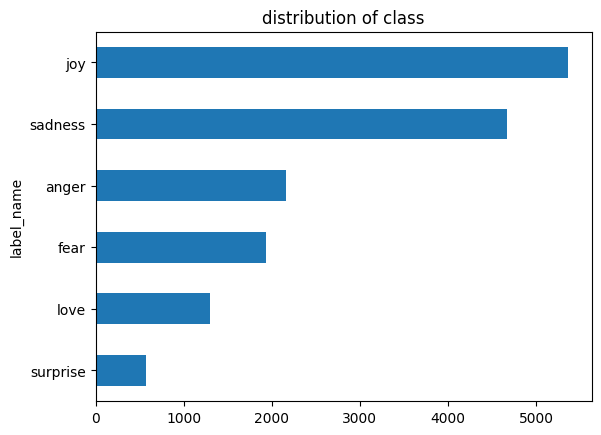

In [39]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("distribution of class")

Transformer models like DistilBERT cannot receive raw strings as input; instead, they
assume the text has been tokenized and encoded as numerical vectors.

 ***Tokenization is the step of breaking down a string into the atomic units used in the model***

#### Character Tokenization

The simplest tokenization scheme is to feed each character individually to the model.

In [40]:
text = "tokenization is the step of breaking down a string into the atomic units used in the model"
tokenized_text = list(text)
print(tokenized_text)

['t', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', ' ', 'i', 's', ' ', 't', 'h', 'e', ' ', 's', 't', 'e', 'p', ' ', 'o', 'f', ' ', 'b', 'r', 'e', 'a', 'k', 'i', 'n', 'g', ' ', 'd', 'o', 'w', 'n', ' ', 'a', ' ', 's', 't', 'r', 'i', 'n', 'g', ' ', 'i', 'n', 't', 'o', ' ', 't', 'h', 'e', ' ', 'a', 't', 'o', 'm', 'i', 'c', ' ', 'u', 'n', 'i', 't', 's', ' ', 'u', 's', 'e', 'd', ' ', 'i', 'n', ' ', 't', 'h', 'e', ' ', 'm', 'o', 'd', 'e', 'l']


 Our model expects each character to be
converted to an integer, a process sometimes called `numericalization`.

In [41]:
token_to_idx = {ch:idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token_to_idx)

{' ': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'w': 20, 'z': 21}


this gives us a mapping from each character from sentence to a unique integer

In [42]:
input_ids = [token_to_idx[token] for token in tokenized_text]
print(input_ids)

[18, 14, 10, 5, 13, 9, 21, 1, 18, 9, 14, 13, 0, 9, 17, 0, 18, 8, 5, 0, 17, 18, 5, 15, 0, 14, 6, 0, 2, 16, 5, 1, 10, 9, 13, 7, 0, 4, 14, 20, 13, 0, 1, 0, 17, 18, 16, 9, 13, 7, 0, 9, 13, 18, 14, 0, 18, 8, 5, 0, 1, 18, 14, 12, 9, 3, 0, 19, 13, 9, 18, 17, 0, 19, 17, 5, 4, 0, 9, 13, 0, 18, 8, 5, 0, 12, 14, 4, 5, 11]


In [43]:
categorical_df = pd.DataFrame(
{"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


In [44]:
pd.get_dummies(categorical_df["Name"],dtype = float)

,Bumblebee,Megatron,Optimus Prime
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0


In [45]:
import torch
import torch.nn.functional as F
input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token_to_idx))
one_hot_encodings.shape

torch.Size([90, 22])

For each of the 90 input tokens we now have a one-hot vector with 22 dimensions,
since our vocabulary consists of 22 unique characters.

In [46]:
print(f"Token : {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"Vector : {one_hot_encodings[0]}")


Token : t
Tensor index: 18
Vector : tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])


From our simple example we can see that character-level tokenization ignores any
structure in the text and treats the whole string as a stream of characters. Although
this helps deal with misspellings and rare words, the main drawback is that linguistic
structures such as words need to be learned from the data.

#### Word Tokenization

Instead of splitting the text into the character , if we split by word then it is word tokenization

One simple class of word tokenizers uses whitespace to tokenize the text. We can do
this by applying Python’s split() function directly on the raw text

In [47]:
tokenized_text = text.split()
print(tokenized_text)

['tokenization', 'is', 'the', 'step', 'of', 'breaking', 'down', 'a', 'string', 'into', 'the', 'atomic', 'units', 'used', 'in', 'the', 'model']


Why large vocabularies are problematic:
A 1M-word vocabulary compressed to 1K dimensions in a neural network's first layer = 1 billion weights — comparable to GPT-2's entire parameter count. This makes models expensive to train and hard to maintain.

#### Subword Tokenization

The basic idea behind subword tokenization is to combine the best aspects of charac
ter and word tokenization. On the one hand, we want to split rare words into smaller
units to allow the model to deal with complex words and misspellings. On the other
hand, we want to keep frequent words as unique entities so that we can keep the
length of our inputs to a manageable size.

In [48]:
from transformers import AutoTokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [52]:
from transformers import DistilBertTokenizer

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Let’s examine how this tokenizer works by feeding it our simple “Tokenizing text is a
core task of NLP.” example text

In [53]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 3989, 2003, 1996, 3357, 1997, 4911, 2091, 1037, 5164, 2046, 1996, 9593, 3197, 2109, 1999, 1996, 2944, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Just as with character tokenization, we can see that the words have been mapped to
unique integers in the input_ids field Now that we have the input_ids, we can convert them back
into tokens by using the tokenizer’s convert_ids_to_tokens() method

In [54]:
token = tokenizer.convert_ids_to_tokens(encoded_text["input_ids"])
print(token)

['[CLS]', 'token', '##ization', 'is', 'the', 'step', 'of', 'breaking', 'down', 'a', 'string', 'into', 'the', 'atomic', 'units', 'used', 'in', 'the', 'model', '[SEP]']


The AutoTokenizer class has a convert_tokens_to_string() method for
doing just that, so let’s apply it to our tokens: